# Principal Component Analysis with Cancer Data

In [1]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [2]:
df = pd.read_csv('cancer.csv')

In [3]:
df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [4]:
df.shape

(699, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


In [6]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [7]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [8]:
df = df.drop_duplicates()

In [9]:
df.isnull().sum()

ID                             0
ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [10]:
df.shape

(691, 11)

In [11]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?
df[df['Bare Nuclei']=='?'].count()


ID                             16
ClumpThickness                 16
Cell Size                      16
Cell Shape                     16
Marginal Adhesion              16
Single Epithelial Cell Size    16
Bare Nuclei                    16
Normal Nucleoli                16
Bland Chromatin                16
Mitoses                        16
Class                          16
dtype: int64

In [12]:
# 16 rows are having '?' 

In [13]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values
df = df.replace('?', np.nan)
df = df.apply(lambda x: x.fillna(x.median()),axis=0)

In [14]:
df['Bare Nuclei'] = df['Bare Nuclei'].astype('float64')  

In [15]:
df.head()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,2
1,1002945,5,4,4,5,7,10.0,3,2,1,2
2,1015425,3,1,1,1,2,2.0,3,1,1,2
3,1016277,6,8,8,1,3,4.0,3,7,1,2
4,1017023,4,1,1,3,2,1.0,3,1,1,2


# Q4. Perform bi variate analysis including correlation & pairplots. 


In [16]:
# Check for correlation of variable
df.corr()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
ID,1.000000,-0.059165,-0.043273,-0.042184,-0.066230,-0.047642,-0.091235,-0.059645,-0.054001,-0.036001,-0.079459
ClumpThickness,-0.059165,1.000000,0.643340,0.653752,0.487949,0.517448,0.590841,0.561076,0.535712,0.350354,0.716938
Cell Size,-0.043273,0.643340,1.000000,0.905420,0.713117,0.747111,0.684791,0.759525,0.727239,0.460064,0.817720
Cell Shape,-0.042184,0.653752,0.905420,1.000000,0.690989,0.714393,0.704382,0.738455,0.724693,0.440592,0.817693
Marginal Adhesion,-0.066230,0.487949,0.713117,0.690989,1.000000,0.608477,0.672719,0.669813,0.602453,0.417167,0.701371
Single Epithelial Cell Size,-0.047642,0.517448,0.747111,0.714393,0.608477,1.000000,0.580709,0.620518,0.634058,0.482644,0.681233
Bare Nuclei,-0.091235,0.590841,0.684791,0.704382,0.672719,0.580709,1.000000,0.672687,0.578417,0.343020,0.816787
Normal Nucleoli,-0.059645,0.561076,0.759525,0.738455,0.669813,0.620518,0.672687,1.000000,0.669059,0.343821,0.756618
Bland Chromatin,-0.054001,0.535712,0.727239,0.724693,0.602453,0.634058,0.578417,0.669059,1.000000,0.427644,0.715540
Mitoses,-0.036001,0.350354,0.460064,0.440592,0.417167,0.482644,0.343020,0.343821,0.427644,1.000000,0.424111


In [17]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin

In [18]:
#Let us check for pair plots

C:\Users\sgoud\AppData\Local\Continuum\anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\Users\sgoud\AppData\Local\Continuum\anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
C:\Users\sgoud\AppData\Local\Continuum\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


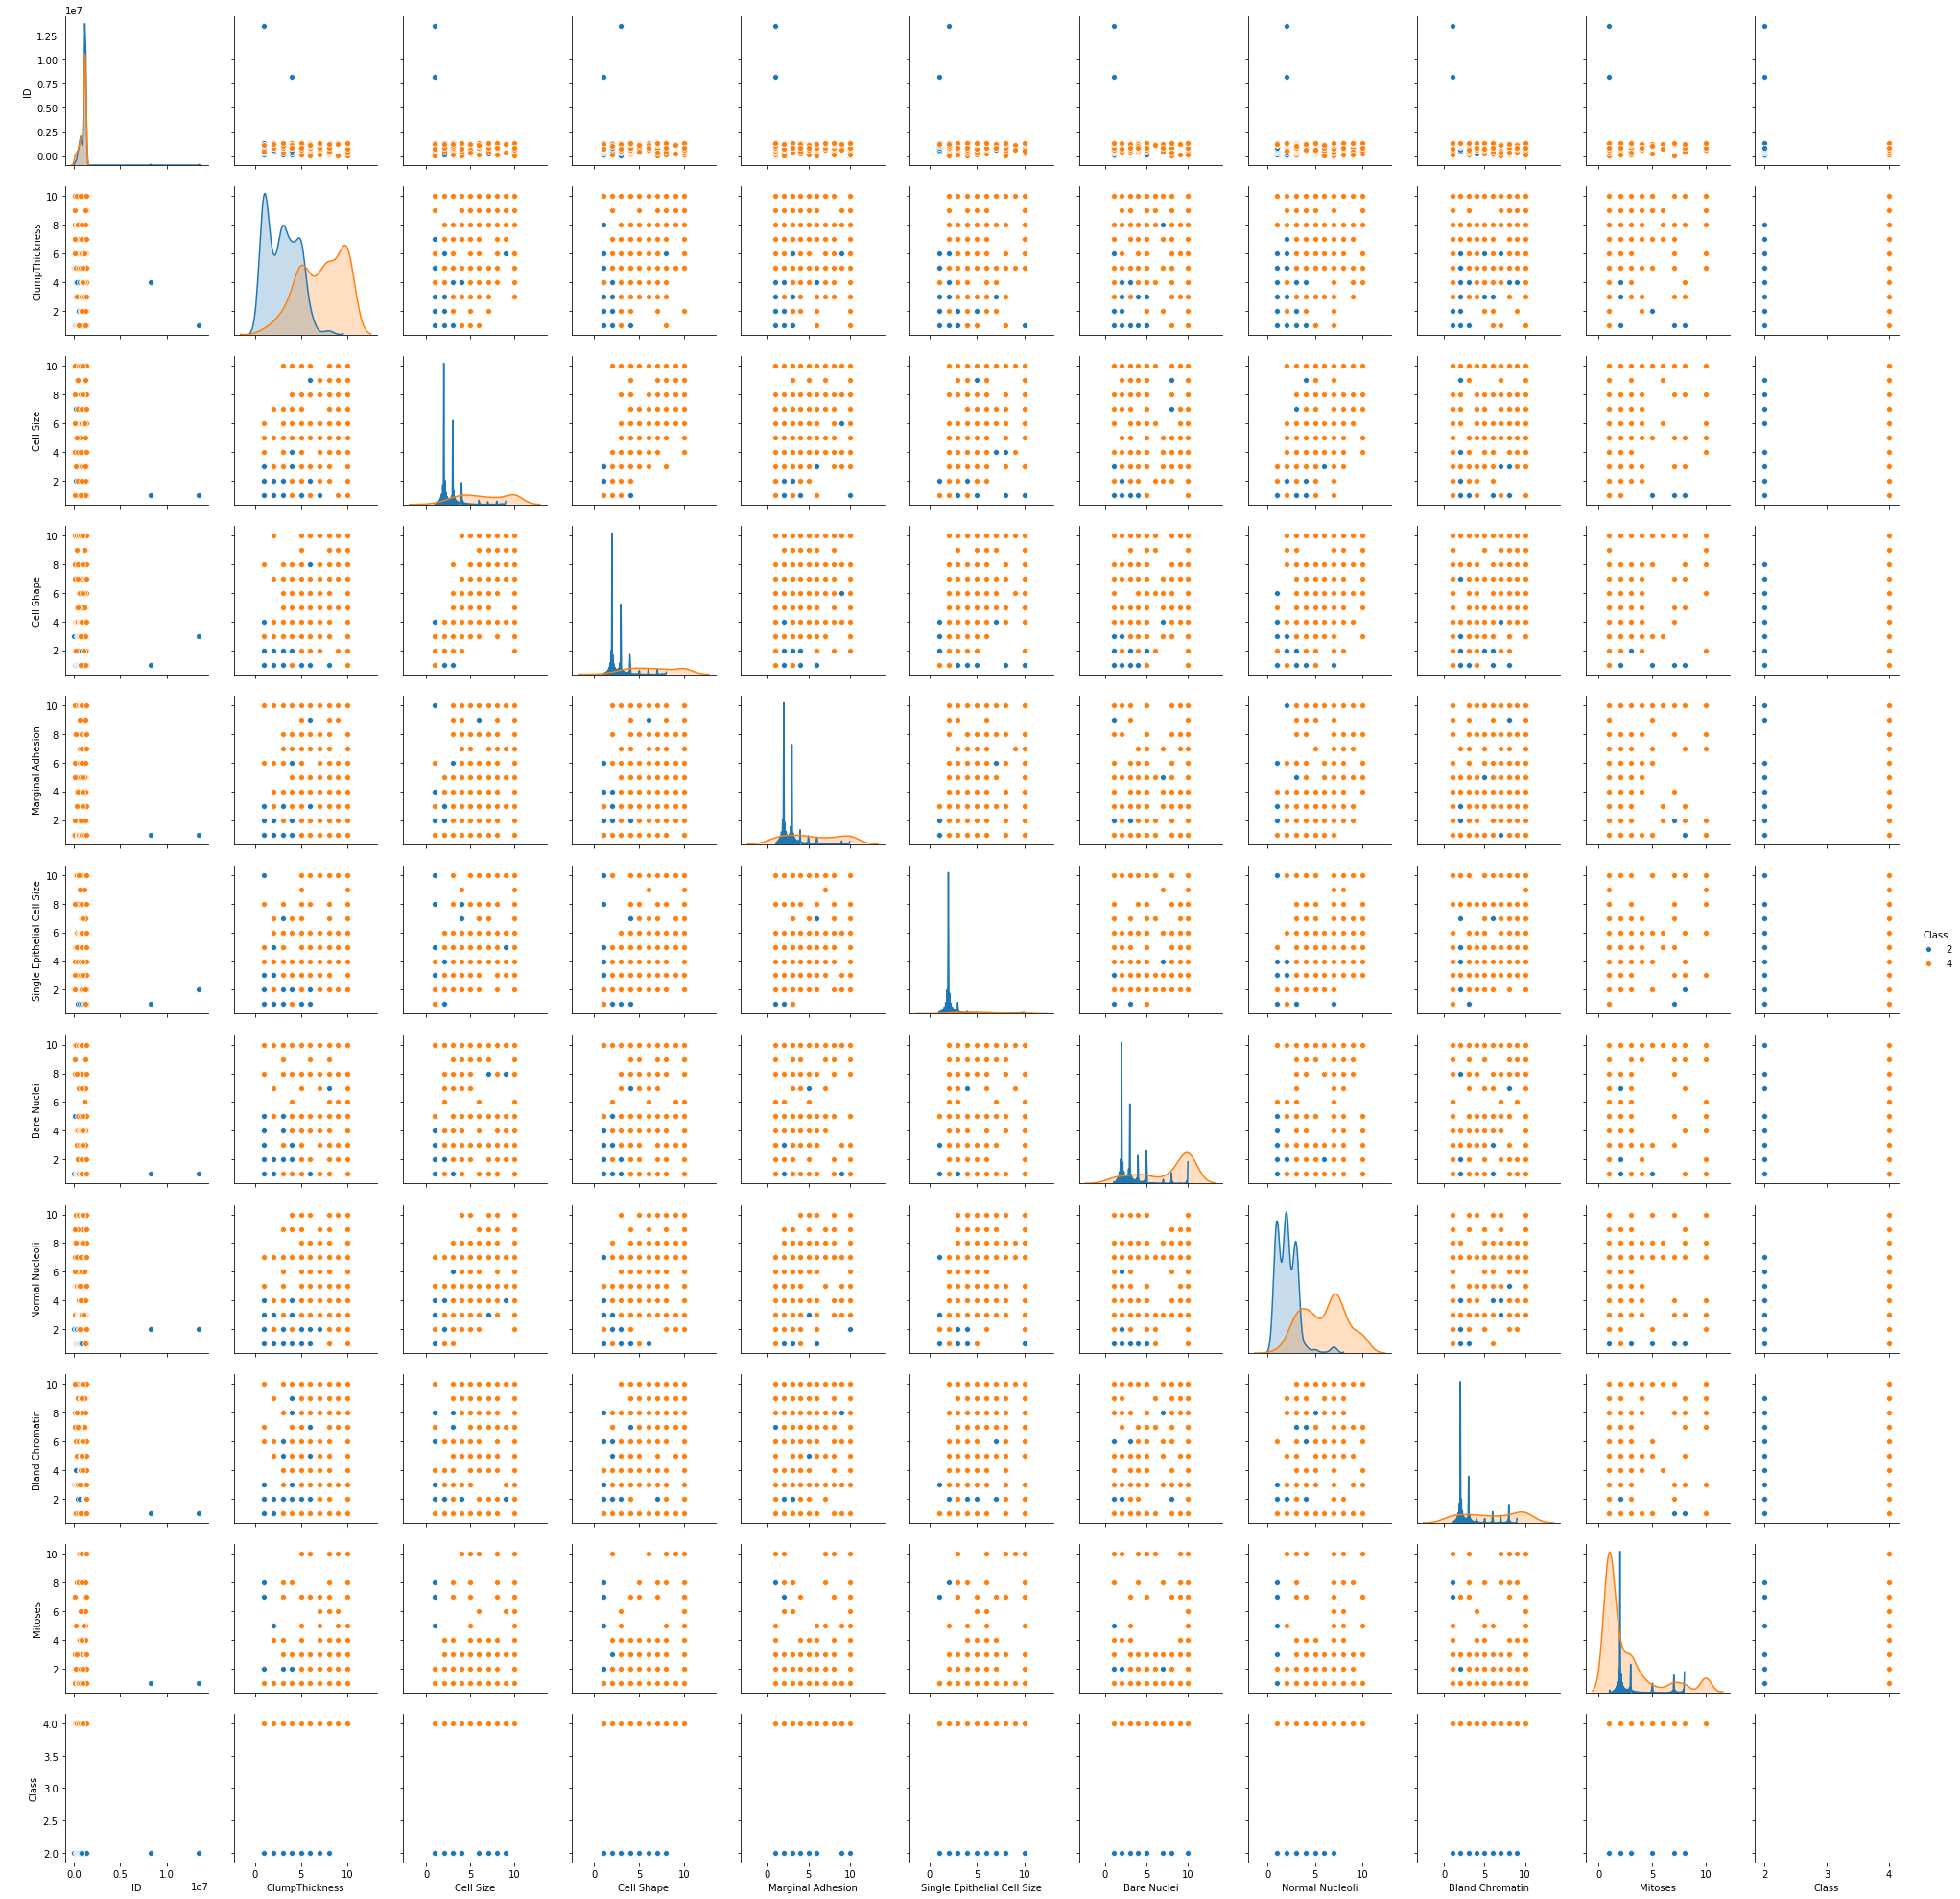

In [19]:
sns.pairplot(df, diag_kind = "kde", hue = "Class")

In [20]:
# Target variable shows high correlation with most of these variables

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [21]:
# Removing unwanted ID column from dataframe
df = df.drop(["ID"], axis=1)

In [22]:
# The data contains extreme values as 10 for many rows for various attributes, 
# but as these are in range these are considered as extreme values.
#    #  Attribute                     Domain
#    -- -----------------------------------------
#    1. Sample code number            id number
#    2. Clump Thickness               1 - 10
#    3. Uniformity of Cell Size       1 - 10
#    4. Uniformity of Cell Shape      1 - 10
#    5. Marginal Adhesion             1 - 10
#    6. Single Epithelial Cell Size   1 - 10
#    7. Bare Nuclei                   1 - 10
#    8. Bland Chromatin               1 - 10
#    9. Normal Nucleoli               1 - 10
#   10. Mitoses                       1 - 10


In [23]:
# Standardize Columns
from scipy.stats import zscore
numeric_cols = df.drop('Class', axis=1)
class_type  = df.pop("Class")
numeric_cols = numeric_cols.apply(zscore)
df = numeric_cols.join(class_type)   
df.head()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,0.203667,-0.700940,-0.744202,-0.637077,-0.551021,-0.686127,-0.178483,-0.614468,-0.34459,2
1,0.203667,0.286185,0.270085,0.759339,1.723505,1.804838,-0.178483,-0.288106,-0.34459,2
2,-0.507110,-0.700940,-0.744202,-0.637077,-0.551021,-0.409353,-0.178483,-0.614468,-0.34459,2
3,0.559055,1.602353,1.622467,-0.637077,-0.096116,0.144195,-0.178483,1.343706,-0.34459,2
4,-0.151722,-0.700940,-0.744202,0.061131,-0.551021,-0.686127,-0.178483,-0.614468,-0.34459,2


# Q6 Create a covariance matrix for identifying Principal components

In [24]:
# PCA
# Step 1 - Create covariance matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
X_std = StandardScaler().fit_transform(df)
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00144928 0.64427196 0.65469961 0.48865637 0.51819771 0.59169728
  0.56188952 0.53648819 0.35086138 0.7179775 ]
 [0.64427196 1.00144928 0.90673173 0.71415051 0.74819397 0.68578334
  0.760626   0.72829333 0.46073106 0.81890491]
 [0.65469961 0.90673173 1.00144928 0.69199047 0.71542879 0.7054026
  0.73952487 0.72574349 0.44123095 0.8188784 ]
 [0.48865637 0.71415051 0.69199047 1.00144928 0.60935911 0.67369366
  0.67078345 0.6033266  0.41777184 0.7023873 ]
 [0.51819771 0.74819397 0.71542879 0.60935911 1.00144928 0.58155073
  0.62141694 0.63497707 0.48334351 0.68221993]
 [0.59169728 0.68578334 0.7054026  0.67369366 0.58155073 1.00144928
  0.67366165 0.57925498 0.34351675 0.81797039]
 [0.56188952 0.760626   0.73952487 0.67078345 0.62141694 0.67366165
  1.00144928 0.67002891 0.34431924 0.75771481]
 [0.53648819 0.72829333 0.72574349 0.6033266  0.63497707 0.57925498
  0.67002891 1.00144928 0.42826329 0.71657711]
 [0.35086138 0.46073106 0.44123095 0.41777184 0.48334351 0.

C:\Users\sgoud\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\sgoud\AppData\Local\Continuum\anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


# Q7 Identify eigen values and eigen vector

In [25]:
# Step 2- Get eigen values and eigen vector

In [26]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)

Eigen Vectors 
%s [[-0.28594386  0.15822652 -0.81819504 -0.02247707 -0.16839258  0.09740708
  -0.02399121  0.27064219  0.30031774 -0.14626833]
 [-0.35554273  0.01506343  0.08186888 -0.74153894  0.00519494  0.20689509
  -0.12876553 -0.45284183  0.20453103  0.102314  ]
 [-0.35258343  0.0530098   0.02478914  0.64549863 -0.20447251  0.19065306
  -0.08543557 -0.59007122  0.13272726  0.06583689]
 [-0.31119475  0.01417964  0.38033928  0.04539421  0.01916057 -0.4862085
  -0.00883995  0.16127468  0.53868075 -0.45078566]
 [-0.31122679 -0.20846124  0.19375843  0.06380737 -0.01811469  0.31892242
  -0.70915403  0.39983637 -0.21935271 -0.0717235 ]
 [-0.31653835  0.24728187 -0.06189079 -0.1129177  -0.40302253 -0.54397873
  -0.05414084 -0.07769035 -0.59559162 -0.0061527 ]
 [-0.32416678  0.19369696  0.22095535  0.05272619 -0.07593682  0.01804264
   0.25481088  0.3947641   0.17234083  0.74110424]
 [-0.31366951 -0.05269479  0.17996796 -0.03243582 -0.11136872  0.45237692
   0.6133675   0.14193235 -0.27547

# Q8 Find variance and cumulative variance by each eigen vector

In [27]:
eigen_pairs = [(np.abs(eig_vals[i]), eig_vecs[ :, i]) for i in range(len(eig_vals))]
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

In [28]:
print("Variance Explained", var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Variance Explained [67.2542743500303, 7.9277185302925375, 5.496789602802184, 4.713370367166546, 3.7054881181839217, 3.132205224596759, 2.9319962170163465, 2.6395037790025233, 1.301226635120166, 0.8974271757887099]
Cumulative Variance Explained [ 67.25427435  75.18199288  80.67878248  85.39215285  89.09764097
  92.22984619  95.16184241  97.80134619  99.10257282 100.        ]


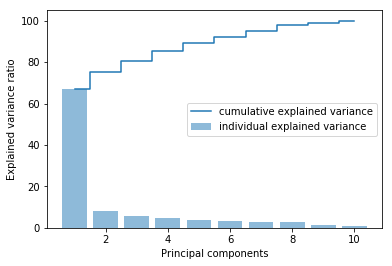

In [29]:
plt.bar(range(1,11), var_exp, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,11),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [30]:
from sklearn.decomposition import PCA
pca = PCA(n_components=7)
principalComponents = pca.fit_transform(X_std)
principalDf = pd.DataFrame(data = principalComponents
             , columns = ['PC1', 'PC2','PC3','PC4','PC5','PC6','PC7'])

In [31]:
principalDf.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-1.620572,-0.112542,0.528928,0.126596,-0.075264,-0.316680,0.242750
1,1.121320,-0.325602,-0.453418,-0.636741,1.698516,0.667002,-0.534377
2,-1.736205,-0.068520,-0.035497,-0.093198,-0.077332,0.061623,0.345011
3,1.153043,-0.336234,0.183308,1.668201,-0.401484,-0.074882,-0.277218
4,-1.504915,-0.066211,-0.027405,-0.247496,-0.077618,-0.586062,-0.020010


# Q10 Find correlation between components and features

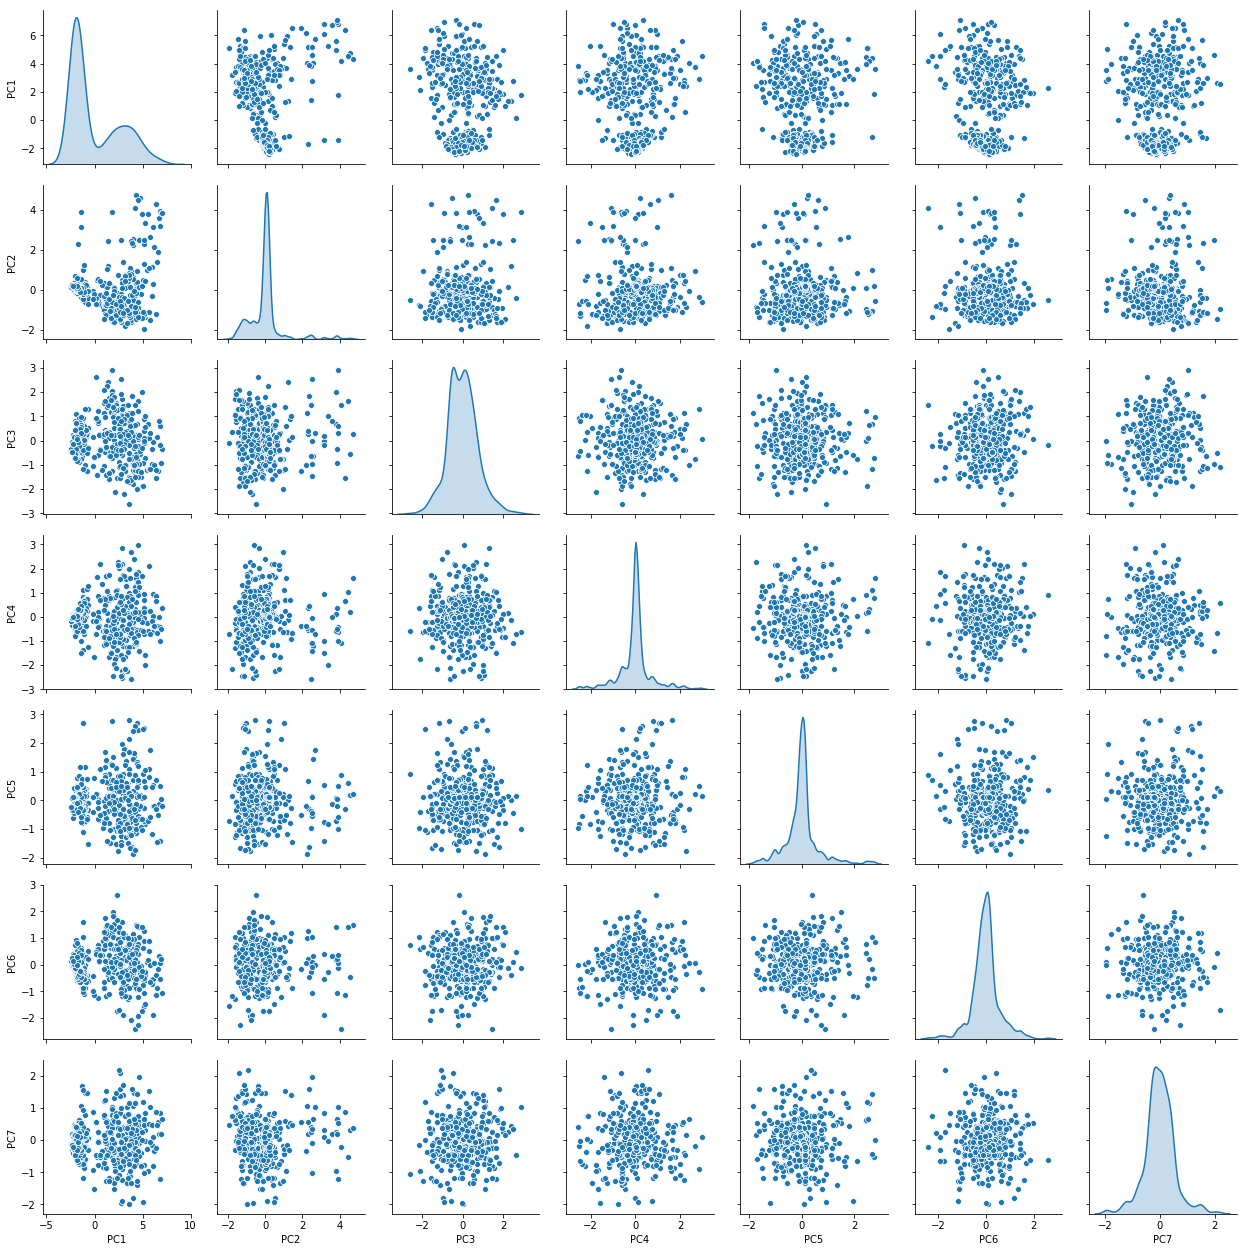

In [32]:
sns.pairplot(principalDf,diag_kind = "kde")

In [ ]:
# After PCA, we can observe that the data is better distributed than before ( i.e., distribution in original data).
# Also, there is now less correlation between Principal Components.